In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [5]:
start_idx = 40 + 12  # 52
end_idx = start_idx + 128  # 180

X_mel = data.iloc[:, start_idx:end_idx].values
X_mel.shape

(588, 128)

In [6]:
import numpy as np

X_log_mel = np.log(X_mel + 1e-9)
X_log_mel.shape

(588, 128)

In [7]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
y = data.iloc[:, -2].values
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)
y1 = to_categorical(y_encoded)

In [8]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(588, 7))

In [9]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [10]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [11]:
X3=pd.DataFrame(X_log_mel)
X3

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-2.591298,-2.701665,-2.322109,-1.648687,-1.562500,-2.400119,-2.426049,-2.047893,-0.395044,0.900927,...,-6.355681,-5.726539,-5.113979,-5.249745,-5.667781,-5.874017,-5.775069,-5.658840,-5.347026,-5.160248
1,-3.486943,-3.200485,-3.087816,-3.120806,-3.708481,-4.195284,-3.480186,-2.112189,-1.000056,-0.725305,...,-5.071490,-4.460240,-4.480657,-4.615092,-4.752931,-4.598418,-4.393443,-4.750788,-4.689831,-4.510265
2,-3.776323,-3.983576,-3.999550,-4.086998,-4.299324,-4.751933,-4.702789,-3.163757,-0.809103,-0.344084,...,-6.257104,-6.058100,-6.199131,-6.744846,-6.536798,-7.045228,-7.325776,-7.165476,-6.622130,-6.136172
3,-3.427394,-3.449937,-2.759862,-2.326482,-2.363158,-2.736103,-3.015079,-2.559064,-1.329913,-0.937866,...,-6.465669,-5.393337,-5.119704,-5.290111,-5.607510,-4.832221,-4.596084,-4.510250,-4.685270,-5.573876
4,-2.994737,-2.341607,-2.039231,-1.751231,-1.874648,-1.666606,-1.964283,-2.513602,-0.888776,0.729545,...,-6.764409,-6.784556,-6.687893,-6.162661,-5.742924,-5.723620,-5.820656,-6.219142,-6.811945,-6.856505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-5.208801,-4.954617,-3.152222,-0.367571,-0.434424,-2.561776,-3.376981,-0.660193,-0.312700,-1.558463,...,-10.253526,-10.063559,-9.846361,-10.187035,-9.847085,-9.899414,-9.727898,-9.647932,-9.178421,-9.312127
584,-4.269473,-4.253503,-3.954406,-1.210248,-0.758648,-1.431348,-3.500041,-1.903650,-0.843932,-1.562413,...,-6.236467,-6.974568,-7.807931,-7.989664,-8.004551,-7.351805,-7.415083,-7.619327,-7.392112,-7.258588
585,-4.918647,-6.277942,-2.966220,-0.392361,-1.045584,-2.892204,-2.729050,-0.206079,-0.685957,-2.308881,...,-8.481708,-8.917450,-10.064571,-10.309476,-10.482660,-10.089193,-10.139061,-9.978203,-9.412009,-9.316542
586,-4.394429,-5.255724,-3.579132,-1.312699,-1.809550,-4.222958,-2.969503,-1.231381,-1.551968,-2.846124,...,-7.761727,-8.304231,-8.848653,-9.319368,-9.174198,-9.212412,-9.236341,-9.206491,-9.198653,-9.514162


In [14]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=585
num_fea=125
a=create_index(kfold,totalsize)
savedir='emovo_log_mel'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y[train_idx], y[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 470 | Test: 118
Top 125 features: [119 120 126 125 127 123 107 100  99  97] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2553 - loss: 1.9197 - val_accuracy: 0.2034 - val_loss: 1.9417
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4043 - loss: 1.5140 - val_accuracy: 0.1525 - val_loss: 1.9537
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5021 - loss: 1.3860 - val_accuracy: 0.1441 - val_loss: 1.9776
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6021 - loss: 1.2324 - val_accuracy: 0.1441 - val_loss: 2.0054
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6213 - loss: 1.1737 - val_accuracy: 0.1610 - val_loss: 2.0246
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6638 - loss: 1.1182 - val_accuracy: 0.1780 - val_loss: 2.0414
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7447 - loss: 1.0037 - val_accuracy: 0.1441 - val_loss: 2.0562
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7511 - loss: 0.9835 - val_accuracy: 0.1441 - val_l


===== Fold 1 =====
Train: 470 | Test: 118
Top 125 features: [127 125 123 122 126 124 114 118 121 119] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2675 - loss: 1.8778 - val_accuracy: 0.1368 - val_loss: 1.9434
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3928 - loss: 1.5515 - val_accuracy: 0.1368 - val_loss: 1.9622
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4713 - loss: 1.3840 - val_accuracy: 0.1368 - val_loss: 1.9819
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5308 - loss: 1.2420 - val_accuracy: 0.1368 - val_loss: 2.0021
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6667 - loss: 1.1272 - val_accuracy: 0.1368 - val_loss: 2.0202
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6900 - loss: 1.0724 - val_accuracy: 0.1368 - val_loss: 2.0333
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7176 - loss: 1.0314 - val_accuracy: 0.1368 - val_loss: 2.0397
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7410 - loss: 0.9841 - val_accuracy: 0.1368 - val_l

Fold 3 Test Accuracy: 0.7692

===== Fold 4 =====
Train: 471 | Test: 117
Top 125 features: [124 123 126 125 127 122 116 118 117 113] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2718 - loss: 1.8946 - val_accuracy: 0.2137 - val_loss: 1.9334
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4374 - loss: 1.4765 - val_accuracy: 0.1880 - val_loss: 1.9354
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5478 - loss: 1.2963 - val_accuracy: 0.1368 - val_loss: 1.9427
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6539 - loss: 1.1611 - val_accuracy: 0.1368 - val_loss: 1.9476
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6752 - loss: 1.0869 - val_accuracy: 0.1368 - val_loss: 1.9555
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6858 - loss: 1.0704 - val_accuracy: 0.1368 - val_loss: 1.9647
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7113 - loss: 1.0350 - val_accuracy: 0.1368 - val_loss: 1.9793
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7771 - loss: 0.9450 - val_accuracy: 0.1368 - val_l

Fold 4 Test Accuracy: 0.7692

===== Cross-validation results =====
Fold 0: Loss=0.8398, Accuracy=0.7627
Fold 1: Loss=0.9787, Accuracy=0.6780
Fold 2: Loss=0.7108, Accuracy=0.8475
Fold 3: Loss=0.8255, Accuracy=0.7692
Fold 4: Loss=0.8132, Accuracy=0.7692

Average accuracy: 0.7653


In [15]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emovo_log_mel'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


Fold 0: Accuracy = 76.27%
Fold 1: Accuracy = 67.80%


Fold 2: Accuracy = 84.75%
Fold 3: Accuracy = 76.92%
Fold 4: Accuracy = 76.92%

Mean Accuracy: 76.53%
SD Accuracy: 5.37
95% CI: ± 4.71


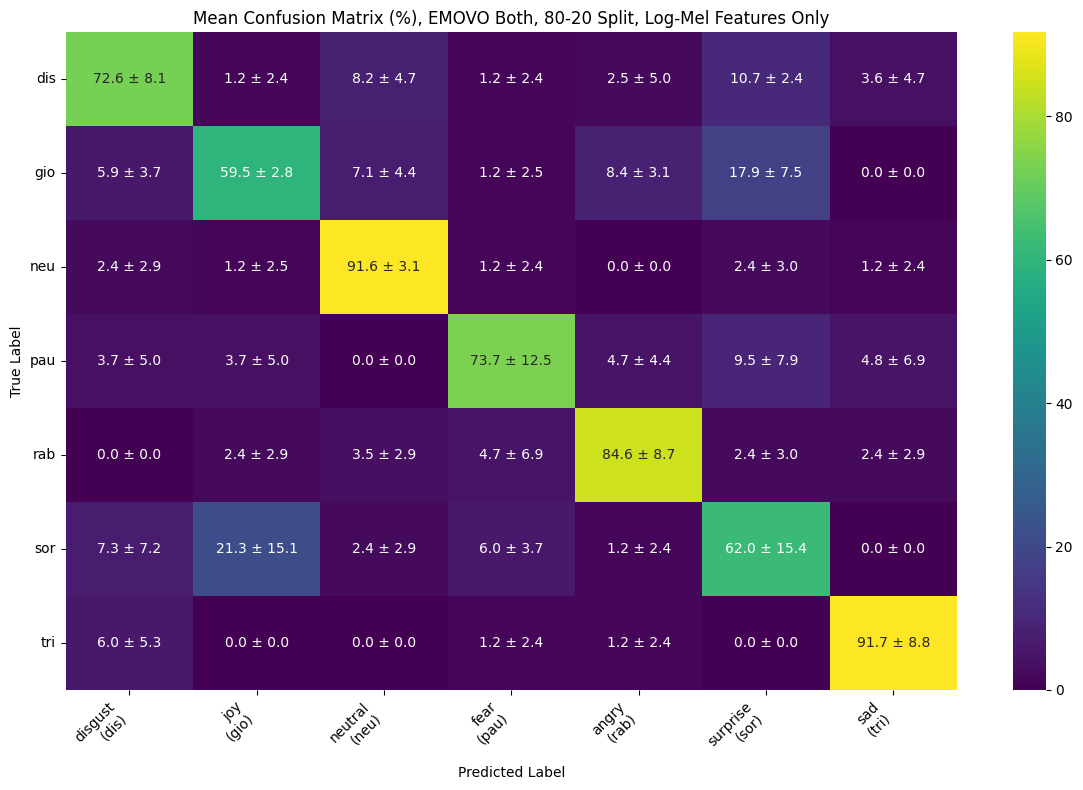

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(y_list, rotation=0)

plt.title("Mean Confusion Matrix (%), EMOVO Both, 80-20 Split, Log-Mel Features Only")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
